# Stage 07: ML1, the feature judge

**P(this arrangement is plausible), learned from six scale-invariant
descriptors — with the circular negatives replaced, which is the headline
change of this stage.**

## The circularity, and its fix

The previous classifier built its negatives by corrupting *features*: it
multiplied `cov_x` and `cov_y`, overwrote `interior_ratio`, stretched
`aspect_ratio`, and recomputed `regularity` — four of the six features the
model then read back. The model's job reduced to spotting which features
had been touched; a one-split stump on `cov_x` alone recovered most of the
headline ROC AUC. That is a property of the negative generator, not of
building geometry.

The rebuilt negatives are generated in **geometry space**, on the column
coordinates, before any feature is computed — four kinds, cycling evenly:

| kind | construction | what it tests |
|---|---|---|
| `transplant` | another plan's real arrangement rescaled onto this footprint | context: right style, wrong building |
| `jitter` | every coordinate + N(0, 0.35 × median span) | alignment into lines at all |
| `shear` | x' = x + k·y, k ~ ±0.2–0.4 | orthogonality |
| `dropout` | 30% of columns removed, half the rest shifted a span | completeness of the load path |

The features themselves are unchanged and deliberately scale-invariant
(`aspect_ratio, cov_x, cov_y, regularity, interior_ratio, span_ratio_xy`),
because Swiss, CubiCasa and ResPlan are drawn in three different unit
systems. Positives are the derived ground-truth arrangements of the 12,460
plans with coordinates (Swiss `verified` + CubiCasa `relative-scale`), the
seven demo plans excluded before anything is built.

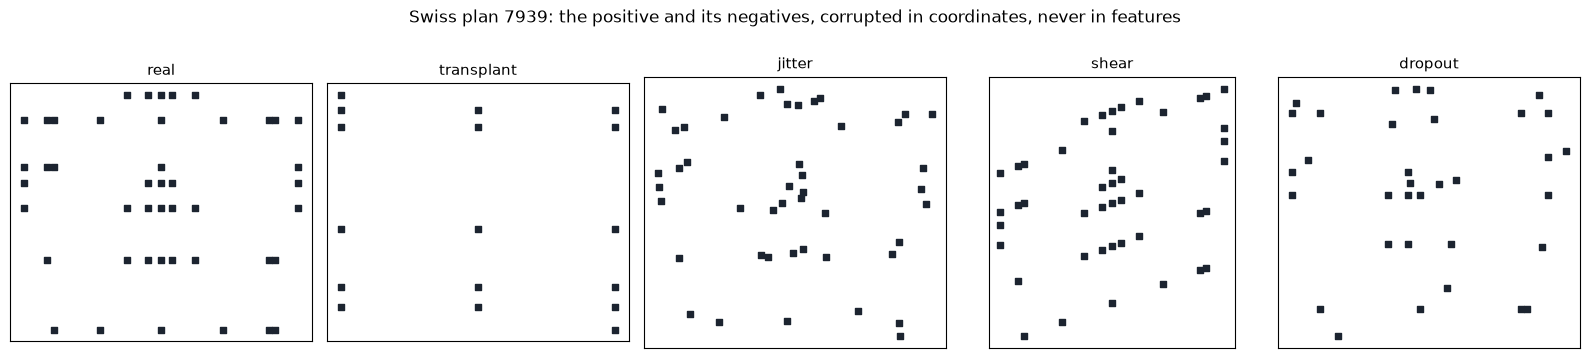

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "09_full_pipeline"))
import pipeline as P

# one real arrangement and its four geometry-space corruptions
corpus = P.load_judge_corpus()
rng = np.random.default_rng(7)
row = corpus.iloc[100]
donor = corpus.points.iloc[2000]
fig, axes = plt.subplots(1, 5, figsize=(16, 3.4))
sets = [("real", row.points)] + [
    (k, P.corrupt_columns(row.points, k, rng, donor=donor))
    for k in P.NEGATIVE_KINDS]
for ax, (name, pts) in zip(axes, sets):
    pts = np.asarray(pts)
    ax.scatter(pts[:, 0], pts[:, 1], s=18, c="#1c2430", marker="s")
    ax.set_title(name, fontsize=11)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"{row.source} plan {row.id}: the positive and its negatives, "
             "corrupted in coordinates, never in features", y=1.04)
fig.tight_layout()
fig.savefig(Path("..") / "figures" / "07_negatives.png", dpi=150,
            bbox_inches="tight")
plt.show()

## Results, with the drop reported rather than hidden

The training script (`train_ml1.py`, whose outputs are read below) fits
gradient boosting on an 80/20 split **grouped by plan**, repeats the split
over five seeds, and reports PR-AUC beside ROC AUC. Against the old
protocol the headline falls from 0.947 to about 0.86. That drop *is* the
finding: about a tenth of the old number was the model reading its own
negative generator. The stump baseline confirms the rest is genuinely
multivariate — no single feature gets close on the new task.

In [2]:
res = pd.read_csv(Path("..") / "data" / "ml1_results.csv")
pooled = res[(res.experiment == "grouped-split") & (res.test == "pooled")]
stump = res[res.experiment == "stump-best"]
print(f"ML1, grouped split x5:  ROC AUC {pooled.roc_auc.mean():.3f} "
      f"± {pooled.roc_auc.std():.3f}   PR AUC {pooled.pr_auc.mean():.3f} "
      f"± {pooled.pr_auc.std():.3f}")
print(f"best single-feature stump: ROC AUC {stump.roc_auc.mean():.3f} "
      f"± {stump.roc_auc.std():.3f}")
print()
per_source = res[(res.experiment == "grouped-split") &
                 (res.test.isin(["Swiss", "CubiCasa"]))]
print("per source (test rows of the pooled model):")
print(per_source.groupby("test")[["roc_auc", "pr_auc"]].mean().round(3))

ML1, grouped split x5:  ROC AUC 0.862 ± 0.006   PR AUC 0.831 ± 0.008
best single-feature stump: ROC AUC 0.679 ± 0.008

per source (test rows of the pooled model):
          roc_auc  pr_auc
test                     
CubiCasa    0.774   0.747
Swiss       0.896   0.865


In [3]:
loso = res[res.experiment == "leave-one-source-out"]
kinds = res[res.experiment == "per-negative-kind"]
print("leave-one-source-out (loophole L14):")
print(loso[["train", "test", "roc_auc", "pr_auc"]].round(3).to_string(index=False))
print()
print("difficulty by negative kind (real vs that kind only):")
print(kinds[["test", "roc_auc", "pr_auc"]].round(3).to_string(index=False))

leave-one-source-out (loophole L14):
   train     test  roc_auc  pr_auc
   Swiss CubiCasa    0.673   0.608
CubiCasa    Swiss    0.805   0.727

difficulty by negative kind (real vs that kind only):
      test  roc_auc  pr_auc
transplant    0.668   0.884
    jitter    0.960   0.989
     shear    0.956   0.984
   dropout    0.881   0.965


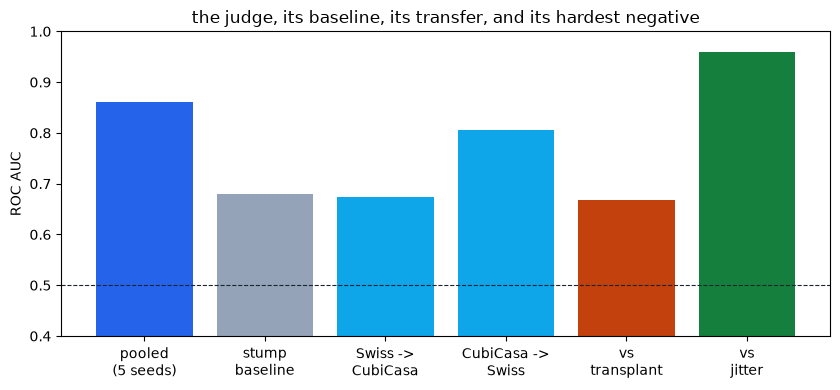

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 4))
bars = [("pooled\n(5 seeds)", pooled.roc_auc.mean(), "#2563eb"),
        ("stump\nbaseline", stump.roc_auc.mean(), "#94a3b8"),
        ("Swiss ->\nCubiCasa", loso[loso.train == "Swiss"].roc_auc.iloc[0], "#0ea5e9"),
        ("CubiCasa ->\nSwiss", loso[loso.train == "CubiCasa"].roc_auc.iloc[0], "#0ea5e9"),
        ("vs\ntransplant", kinds[kinds.test == "transplant"].roc_auc.iloc[0], "#c2410c"),
        ("vs\njitter", kinds[kinds.test == "jitter"].roc_auc.iloc[0], "#15803d")]
ax.bar([b[0] for b in bars], [b[1] for b in bars],
       color=[b[2] for b in bars])
ax.axhline(0.5, color="#1c2430", lw=0.8, ls="--")
ax.set_ylim(0.4, 1.0); ax.set_ylabel("ROC AUC")
ax.set_title("the judge, its baseline, its transfer, and its hardest negative")
fig.tight_layout()
fig.savefig(Path("..") / "figures" / "07_model_performance.png", dpi=150,
            bbox_inches="tight")
plt.show()

## Reading the table honestly

* **Transplants are the hardest negative** (ROC AUC ≈ 0.67): they are real
  arrangements from real buildings, only rescaled — the judge must catch a
  mismatch between arrangement and footprint proportion, not a broken
  geometry. That is the negative class closest to the judge's actual job in
  the pipeline, so the pooled figure should be read alongside it.
* **The transfer gap is real** (Swiss→CubiCasa ≈ 0.67 vs CubiCasa→Swiss
  ≈ 0.81): a model trained on Swiss drafting conventions travels worse
  than the reverse. Cross-source claims lean on the pooled model, and the
  limitation is stated.
* **Class balance is synthetic** (1:1 by construction), so PR-AUC at real
  prevalence is unknowable; both AUCs are reported and neither is claimed
  as a deployment number (loophole L13).

In the pipeline this model is the **V1 judge**: it re-orders the score
function's top 15 through the blend
`combined = z(penalty) + λ·(1 − P(plausible))`, with λ ablated in stage 12
rather than hardcoded.